## 02的可视化

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

def plot_scaling_results(experiment_path, scale_name):
    """
    experiment_path: 实验时间根目录，如 'output/20260326_163751'
    scale_name: 需要画图的参数量档位，如 '30M'
    """
    target_dir = os.path.join(experiment_path, scale_name)
    if not os.path.exists(target_dir):
        print(f"错误: 找不到目录 {target_dir}")
        return

    # 1. 获取该目录下所有的 L{x}.csv 文件
    csv_files = glob.glob(os.path.join(target_dir, "L*.csv"))
    
    # 对文件名进行排序，确保 L2, L3 ... L25 按顺序排列
    def sort_key(s):
        nums = re.findall(r'\d+', os.path.basename(s))
        return int(nums[0]) if nums else 0
    
    csv_files.sort(key=sort_key)

    if not csv_files:
        print(f"在 {target_dir} 中没有找到任何评估 CSV 文件。")
        return

    # 2. 开始绘图
    plt.figure(figsize=(12, 7), dpi=150)
    
    # 使用颜色映射，让难度 L 的颜色产生渐变
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 0.8, len(csv_files))]

    for i, file_path in enumerate(csv_files):
        shard_name = os.path.basename(file_path).replace(".csv", "")
        df = pd.read_csv(file_path)
        
        # 确保数据按信息熵排序（防止乱序写入）
        df = df.sort_values("cumulative_entropy")

        plt.plot(
            df["cumulative_entropy"], 
            df["eval_loss"], 
            label=f"{shard_name}",
            color=colors[i],
            linewidth=1.5,
            alpha=0.8
        )

    # 3. 装饰图表
    plt.title(f"Logic Reasoning Scaling Law - Model Scale: {scale_name}", fontsize=14)
    plt.xlabel("Cumulative Training Entropy (bits)", fontsize=12)
    plt.ylabel("Evaluation Loss", fontsize=12)
    
    # 网格线
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 侧边栏图例（因为 L 很多，放在外面比较好）
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    
    plt.tight_layout()

    # # 4. 保存与展示
    # save_path = os.path.join(target_dir, f"scaling_curve_{scale_name}.png")
    # plt.savefig(save_path)
    # print(f"图表已保存至: {save_path}")
    plt.show()

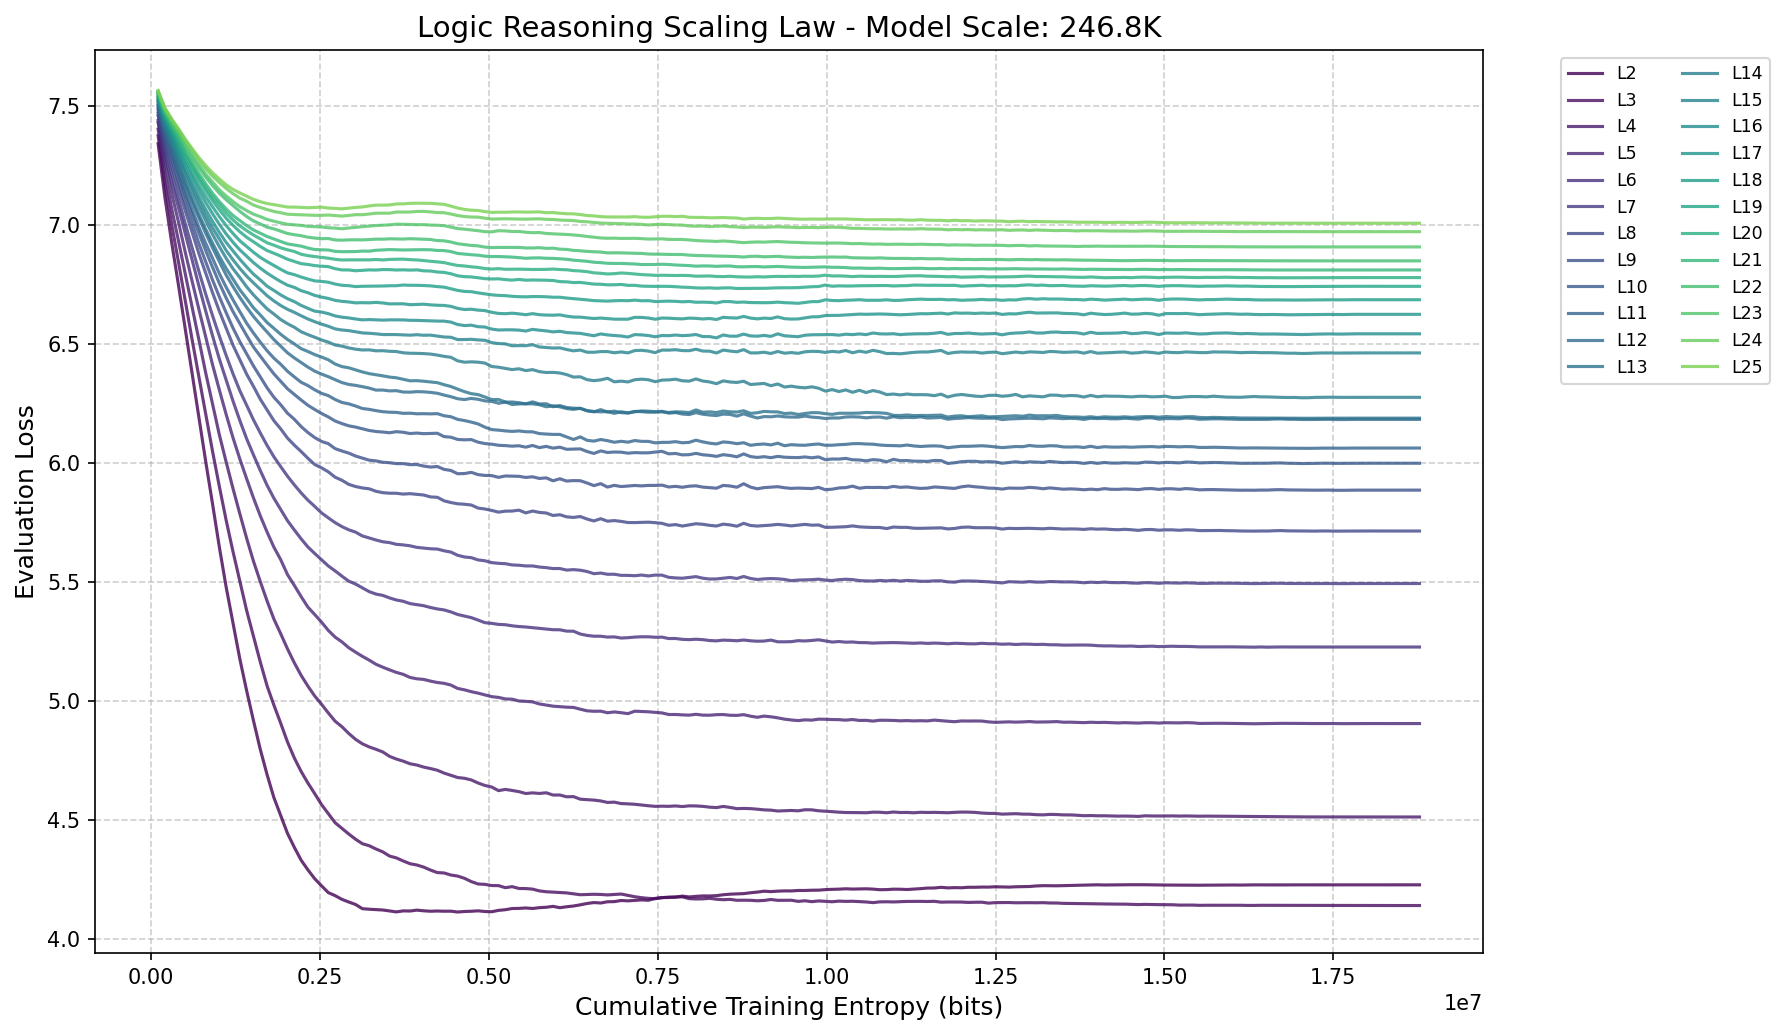

In [2]:
plot_scaling_results("output/20260326_160608", "246.8K")

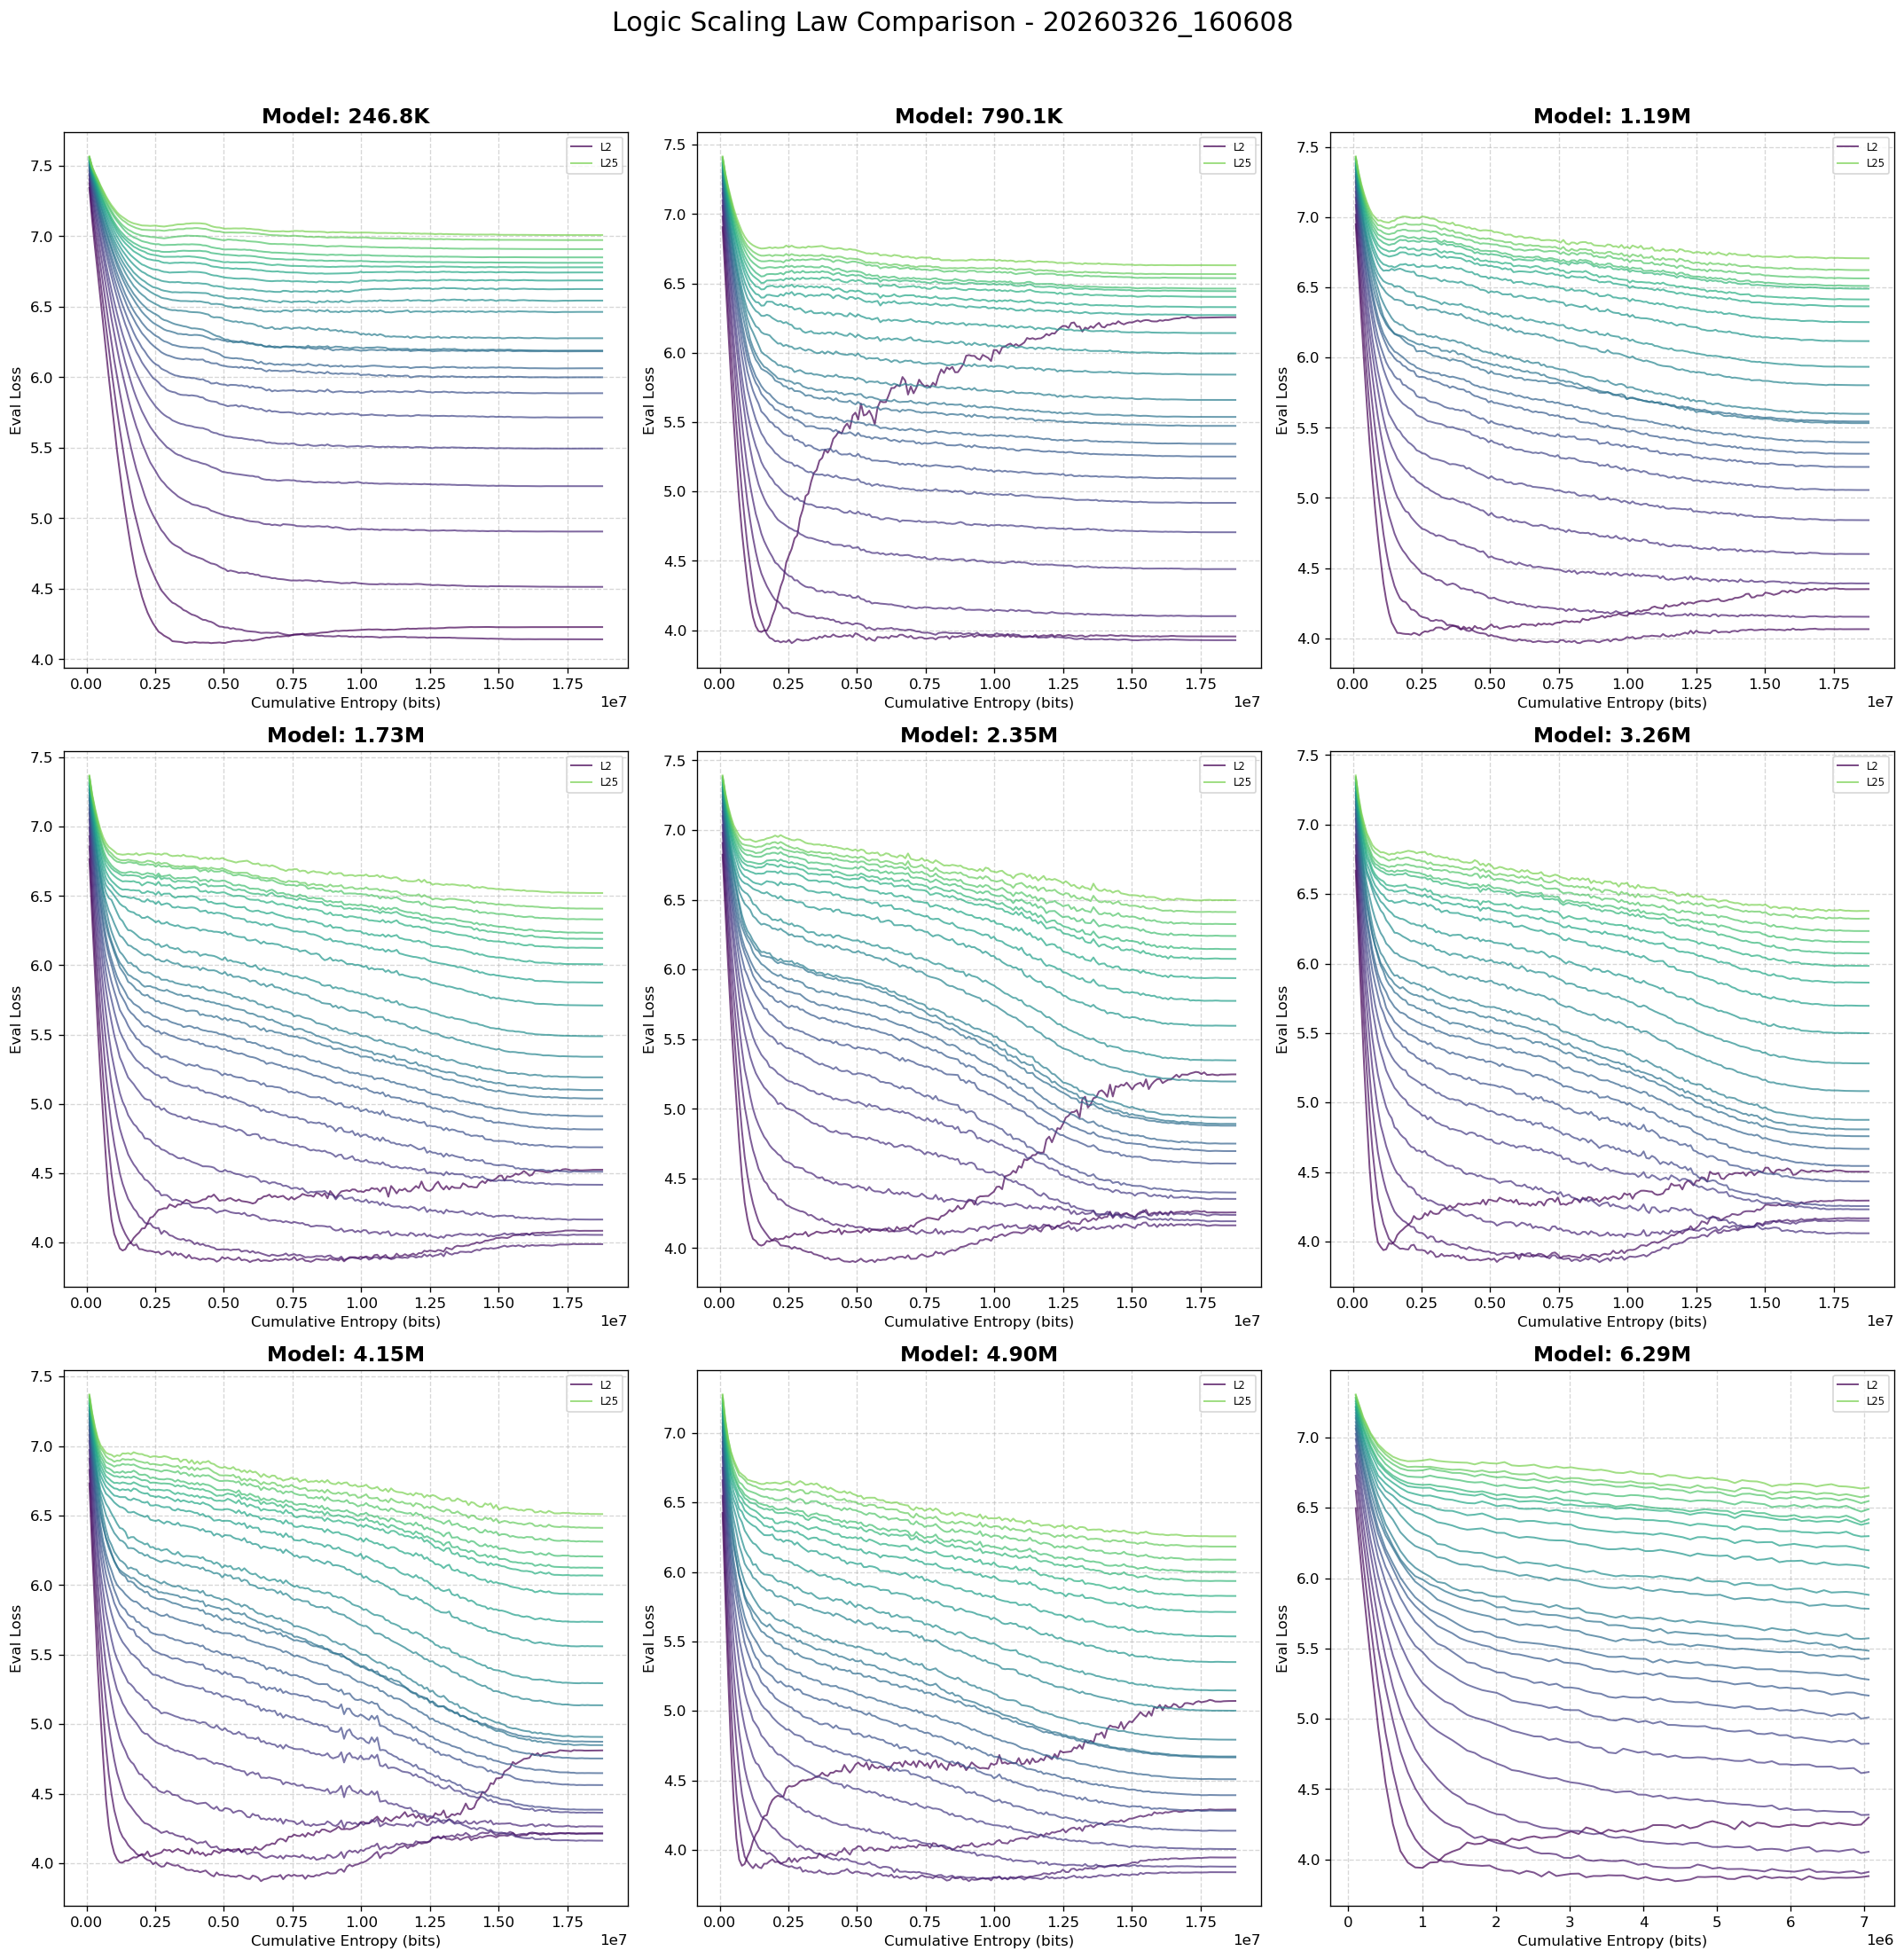

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

def plot_all_scales_combined(experiment_path):
    """
    自动判断 experiment_path 下的模型文件夹，并拼图展示。
    一行展示 3 个模型的 Scaling Law 曲线。
    """
    # 1. 自动识别子目录（排除非文件夹和隐藏文件）
    all_scales = [d for d in os.listdir(experiment_path) 
                  if os.path.isdir(os.path.join(experiment_path, d)) and not d.startswith('.')]
    
    # 按照参数量大致排序 (尝试提取数字，如 750K -> 750)
    def scale_sort_key(s):
        num = re.findall(r'(\d+\.?\d*)', s)
        if not num: return 0
        val = float(num[0])
        return val * 1000 if 'M' in s.upper() else val

    all_scales.sort(key=scale_sort_key)
    
    if not all_scales:
        print("未发现任何模型结果文件夹。")
        return

    # 2. 计算布局：一行 3 个图
    num_plots = len(all_scales)
    cols = 3
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows), dpi=120)
    axes = axes.flatten() if num_plots > 1 else [axes]

    # 排序 L 的辅助函数
    def l_sort_key(s):
        nums = re.findall(r'\d+', os.path.basename(s))
        return int(nums[0]) if nums else 0

    # 3. 遍历每个模型绘制子图
    for idx, scale_name in enumerate(all_scales):
        ax = axes[idx]
        target_dir = os.path.join(experiment_path, scale_name)
        csv_files = glob.glob(os.path.join(target_dir, "L*.csv"))
        csv_files.sort(key=l_sort_key)

        if not csv_files:
            ax.set_title(f"{scale_name} (No Data)")
            continue

        # 设置颜色渐变
        cmap = plt.get_cmap('viridis')
        colors = [cmap(i) for i in np.linspace(0, 0.8, len(csv_files))]

        for i, file_path in enumerate(csv_files):
            shard_name = os.path.basename(file_path).replace(".csv", "")
            df = pd.read_csv(file_path)
            df = df.sort_values("cumulative_entropy")

            ax.plot(
                df["cumulative_entropy"], 
                df["eval_loss"], 
                label=f"{shard_name}",
                color=colors[i],
                linewidth=1.2,
                alpha=0.7
            )

        ax.set_title(f"Model: {scale_name}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Cumulative Entropy (bits)")
        ax.set_ylabel("Eval Loss")
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # 每张子图只在 L25 这种关键档位多时显示部分图例，避免挤占空间
        if len(csv_files) <= 10:
            ax.legend(fontsize='x-small', ncol=2)
        else:
            # 太多了就不在子图里全列出来了，或者只列首尾
            handles, labels = ax.get_legend_handles_labels()
            ax.legend([handles[0], handles[-1]], [labels[0], labels[-1]], fontsize='x-small')

    # 4. 隐藏多余的空白子图
    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Logic Scaling Law Comparison - {os.path.basename(experiment_path)}", 
                 fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

# 使用示例
plot_all_scales_combined('output/20260326_160608')